## Celda 1: Importación y Carga de Datos

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar los CSVs
data_path = "data/"
print("Cargando datos...")
companies = pd.read_csv(os.path.join(data_path, "companies.csv"))
transactions = pd.read_csv(os.path.join(data_path, "transactions.csv"))
invoices = pd.read_csv(os.path.join(data_path, "invoices.csv"))
debt_products = pd.read_csv(os.path.join(data_path, "debt_products.csv"))

# CORRECCIÓN: errors='coerce' fuerza las fechas erróneas (como el año 6913) a nulos (NaT)
# Esto evita que la ejecución se rompa.
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
invoices['issuance_date'] = pd.to_datetime(invoices['issuance_date'], errors='coerce')
invoices['due_date'] = pd.to_datetime(invoices['due_date'], errors='coerce')
invoices['payment_date'] = pd.to_datetime(invoices['payment_date'], errors='coerce')

# Eliminar filas donde la fecha vital haya quedado nula
transactions = transactions.dropna(subset=['date'])

print(f"Empresas cargadas: {len(companies)}")
print(f"Transacciones válidas: {len(transactions)}")
print(f"Facturas totales: {len(invoices)}")

Cargando datos...
Empresas cargadas: 1286
Transacciones válidas: 2556437
Facturas totales: 897894


## Celda 2: Seleccionar 3 empresas y visualizar su Flujo de Caja (Cashflow)

El primer paso es entender si la empresa genera o quema dinero mes a mes.

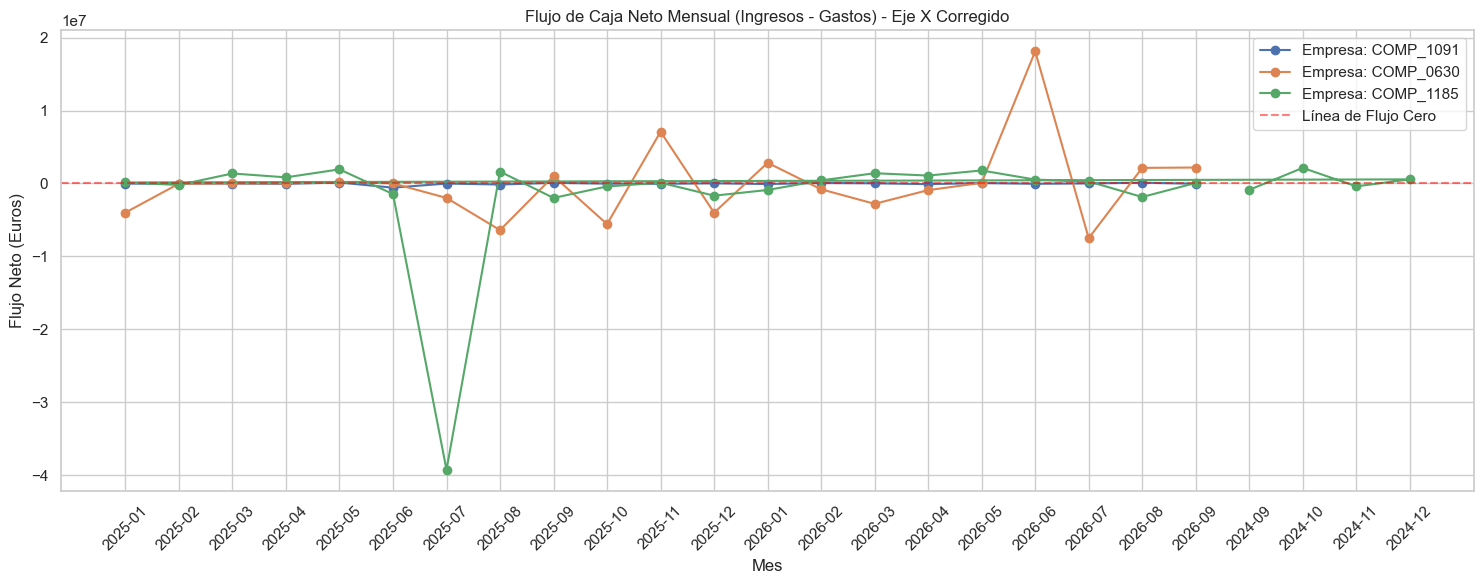

In [20]:
# Crear mes-año
transactions['year_month'] = transactions['date'].dt.to_period('M')

# Agrupar
monthly_cashflow = transactions.groupby(['company_id', 'year_month'])['amount'].sum().reset_index()

# Elegir 3 empresas de las que tienen más actividad
top_companies = transactions['company_id'].value_counts().head(20).index
sample_companies = np.random.choice(top_companies, 3, replace=False)

plt.figure(figsize=(15, 6))
for company in sample_companies:
    data = monthly_cashflow[monthly_cashflow['company_id'] == company].copy()
    
    # CORRECCIÓN DEL GRÁFICO: Ordenamos estrictamente por el periodo temporal
    data = data.sort_values('year_month')
    # Y solo después lo convertimos a string para pintar
    data['year_month_str'] = data['year_month'].astype(str)
    
    plt.plot(data['year_month_str'], data['amount'], marker='o', label=f'Empresa: {company}')

plt.title('Flujo de Caja Neto Mensual (Ingresos - Gastos) - Eje X Corregido')
plt.xlabel('Mes')
plt.ylabel('Flujo Neto (Euros)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Línea de Flujo Cero')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Celda 3: KPI de Dependencia de Deuda (Uso de Líneas de Crédito)

Una de las mejores señales de que una empresa "se tuerce" es que empiece a pagar tarde a sus proveedores o que sus clientes le paguen tarde.

In [21]:
# Rellenar nulos
debt_products['granted'] = debt_products['granted'].fillna(0)
debt_products['outstanding'] = debt_products['outstanding'].fillna(0)

# Líneas de crédito
credit_lines = debt_products[debt_products['type'] == 'lineofcredit'].copy()

# Porcentaje de uso (evitando división por cero)
credit_lines['usage_ratio'] = np.where(
    credit_lines['granted'] > 0, 
    (credit_lines['outstanding'] / credit_lines['granted']) * 100, 
    0
)

# Media de uso por empresa
company_credit_usage = credit_lines.groupby('company_id')['usage_ratio'].mean().reset_index()

at_risk_companies = company_credit_usage[company_credit_usage['usage_ratio'] > 90].sort_values('usage_ratio', ascending=False)
print("Top 5 Empresas asfixiadas (Uso de crédito > 90%):")
display(at_risk_companies.head())

Top 5 Empresas asfixiadas (Uso de crédito > 90%):


,company_id,usage_ratio


## Celda 4: Construcción del Panel Central Mensual (Features)

Analicemos cuánta deuda tienen pendiente frente a lo que les concedieron. Un ratio cercano al 100% en líneas de crédito (lineofcredit) indica que están usando todo el dinero prestado disponible (falta de liquidez).

In [22]:
# --- A. PANEL DE TRANSACCIONES (CAJA) ---
monthly_tx = transactions.groupby(['company_id', 'year_month']).agg(
    ingresos=('amount', lambda x: x[x > 0].sum()),
    gastos=('amount', lambda x: abs(x[x < 0].sum())),
    flujo_neto=('amount', 'sum')
).reset_index()

# Ordenar para medias móviles
monthly_tx = monthly_tx.sort_values(['company_id', 'year_month'])

# Media móvil 3 meses (Distingue bache puntual de caída estructural)
monthly_tx['flujo_neto_3m_avg'] = monthly_tx.groupby('company_id')['flujo_neto'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Burn Ratio: Gastos / Ingresos
monthly_tx['burn_ratio'] = np.where(monthly_tx['ingresos'] > 0, 
                                    monthly_tx['gastos'] / monthly_tx['ingresos'], 
                                    1.5) # Penalizamos meses con 0 ingresos

# --- B. PANEL DE FACTURAS (MOROSIDAD) ---
invoices_clean = invoices.dropna(subset=['payment_date', 'due_date']).copy()
invoices_clean['dias_retraso'] = (invoices_clean['payment_date'] - invoices_clean['due_date']).dt.days
invoices_clean['year_month'] = invoices_clean['due_date'].dt.to_period('M')

monthly_inv = invoices_clean.groupby(['company_id', 'year_month'])['dias_retraso'].mean().reset_index()
monthly_inv.rename(columns={'dias_retraso': 'retraso_medio'}, inplace=True)

# --- C. MASTER PANEL ---
# Cruzamos Caja y Facturas mes a mes
master_panel = pd.merge(monthly_tx, monthly_inv, on=['company_id', 'year_month'], how='left')

# Si no hay facturas ese mes, asumimos comportamiento neutral (0 días de retraso)
master_panel['retraso_medio'] = master_panel['retraso_medio'].fillna(0)

# Cruzamos la Deuda estática (el uso promedio de las líneas de crédito)
master_panel = pd.merge(master_panel, company_credit_usage, on='company_id', how='left')
master_panel['usage_ratio'] = master_panel['usage_ratio'].fillna(0)

print("Master Panel listo. Filas generadas:", len(master_panel))

# Convertir Period a string para poder exportarlo a CSV sin problemas
master_panel['year_month_str'] = master_panel['year_month'].astype(str)

Master Panel listo. Filas generadas: 22179


## Celda 5: Motor del Score de Salud Financiera (0 - 100)

In [23]:
# Partimos de un score neutral
master_panel['score'] = 50.0

# 1. Trayectoria de Caja (Media Móvil 3 Meses) [+/- 15 puntos]
# Si ganan dinero sostenidamente, suben. Si queman estructuralmente, bajan.
master_panel['score'] += np.where(master_panel['flujo_neto_3m_avg'] > 0, 15, -15)

# 2. Burn Ratio Mensual [+/- 10 puntos]
# Gastar mucho menos de lo que ingresas es bueno. Gastar más es malo.
master_panel['score'] += np.where(master_panel['burn_ratio'] < 0.9, 10, 0)
master_panel['score'] += np.where(master_panel['burn_ratio'] > 1.1, -10, 0)

# 3. Retraso en Pagos (El indicador temprano) [+/- 15 puntos]
# Pagar por adelantado da puntos. Pagar con más de 10 días de retraso penaliza fuerte.
master_panel['score'] += np.where(master_panel['retraso_medio'] < 0, 15, 0)
master_panel['score'] += np.where(master_panel['retraso_medio'] > 10, -15, 0)

# 4. Deuda asfixiante [Penaliza hasta -10 puntos]
# Si usan más del 80% de sus líneas de crédito, resta puntos (indica falta de liquidez en cuenta)
master_panel['score'] -= np.where(master_panel['usage_ratio'] > 80, 10, 0)

# Asegurar que el score no se salga de los límites de 0 a 100
master_panel['score'] = master_panel['score'].clip(0, 100)

print("\n--- Distribución del Score Financiero ---")
print(master_panel['score'].describe())

# Ver la trayectoria de una empresa concreta para ver "Cómo cambia mes a mes"
empresa_ejemplo = master_panel[master_panel['company_id'] == sample_companies[0]]
empresa_ejemplo = empresa_ejemplo[['year_month', 'flujo_neto', 'retraso_medio', 'score']].sort_values('year_month')
print(f"\nTrayectoria de Score de {sample_companies[0]}:")
display(empresa_ejemplo)


--- Distribución del Score Financiero ---
count    22179.000000
mean        47.621624
std         21.190225
min         10.000000
25%         25.000000
50%         45.000000
75%         65.000000
max         90.000000
Name: score, dtype: float64

Trayectoria de Score de COMP_1091:


,year_month,flujo_neto,retraso_medio,score
18814,2025-01,-29292.24,0.0,35.0
18815,2025-02,-32688.31,0.0,35.0
18816,2025-03,-12536.58,0.0,35.0
18817,2025-04,-56230.65,0.0,35.0
18818,2025-05,121001.81,0.0,65.0
18819,2025-06,-583742.27,0.0,25.0
18820,2025-07,-18594.64,0.0,35.0
18821,2025-08,-152951.30,0.0,35.0
18822,2025-09,76303.99,0.0,35.0
18823,2025-10,-29563.37,0.0,35.0


In [24]:
# Guardar el dataset limpio y puntuado en la carpeta data
master_panel.to_csv(os.path.join(data_path, 'master_panel_scored.csv'), index=False)
print("Panel exportado a data/master_panel_scored.csv correctamente.")

Panel exportado a data/master_panel_scored.csv correctamente.
